In [1]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Text Processing

from sklearn.feature_extraction.text import TfidfVectorizer


# Train Test Split

from sklearn.model_selection import train_test_split


# Machine Learning Models

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC


# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
# ==========================================
# DOWNLOAD DATASET FROM KAGGLE
# ==========================================

!kaggle datasets download -d hijest/genre-classification-dataset-imdb

Dataset URL: https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb
License(s): other




  0%|          | 0.00/41.7M [00:00<?, ?B/s]
  2%|▏         | 1.00M/41.7M [00:01<01:02, 688kB/s]
  5%|▍         | 2.00M/41.7M [00:01<00:30, 1.36MB/s]
  7%|▋         | 3.00M/41.7M [00:01<00:19, 2.10MB/s]
 10%|▉         | 4.00M/41.7M [00:02<00:13, 2.91MB/s]
 12%|█▏        | 5.00M/41.7M [00:02<00:10, 3.51MB/s]
 14%|█▍        | 6.00M/41.7M [00:02<00:09, 3.96MB/s]
 17%|█▋        | 7.00M/41.7M [00:02<00:07, 4.72MB/s]
 19%|█▉        | 8.00M/41.7M [00:02<00:06, 5.49MB/s]
 22%|██▏       | 9.00M/41.7M [00:02<00:05, 6.34MB/s]
 24%|██▍       | 10.0M/41.7M [00:02<00:04, 7.14MB/s]
 26%|██▋       | 11.0M/41.7M [00:03<00:04, 7.52MB/s]
 29%|██▉       | 12.0M/41.7M [00:03<00:04, 7.31MB/s]
 31%|███       | 13.0M/41.7M [00:03<00:04, 6.71MB/s]
 34%|███▎      | 14.0M/41.7M [00:03<00:04, 6.21MB/s]
 36%|███▌      | 15.0M/41.7M [00:03<00:04, 6.20MB/s]
 38%|███▊      | 16.0M/41.7M [00:03<00:04, 6.38MB/s]
 41%|████      | 17.0M/41.7M [00:04<00:03, 6.63MB/s]
 43%|████▎     | 18.0M/41.7M [00:04<00:03, 6.66MB/s]
 4

In [4]:
# ==========================================
# EXTRACT ZIP FILE
# ==========================================

import zipfile

with zipfile.ZipFile(
    "genre-classification-dataset-imdb.zip",
    'r'
) as zip_ref:

    zip_ref.extractall("movie_dataset")

In [9]:
import os

print(os.listdir("movie_dataset"))

['Genre Classification Dataset']


In [10]:
print(os.listdir(
    "movie_dataset/Genre Classification Dataset"
))

['description.txt', 'test_data.txt', 'test_data_solution.txt', 'train_data.txt']


In [11]:
df = pd.read_csv(
    "movie_dataset/Genre Classification Dataset/train_data.txt",
    sep=':::',
    names=['ID', 'TITLE', 'GENRE', 'DESCRIPTION'],
    engine='python'
)

In [12]:
# ==========================================
# DISPLAY FIRST 5 ROWS
# ==========================================

print(df.head())

   ID                               TITLE       GENRE  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         DESCRIPTION  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  


In [13]:
# ==========================================
# DISPLAY FIRST 5 ROWS
# ==========================================

print(df.head())
# ==========================================
# CHECK MISSING VALUES
# ==========================================

print(df.isnull().sum())

   ID                               TITLE       GENRE  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         DESCRIPTION  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  
ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64


In [14]:
# ==========================================
# IMPORT VISUALIZATION LIBRARIES
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==========================================
# VISUALIZE TOP MOVIE GENRES
# ==========================================

plt.figure(figsize=(12, 6))

sns.countplot(
    y='GENRE',
    data=df,
    order=df['GENRE'].value_counts().index[:10]
)

plt.title("Top 10 Movie Genres")

plt.xlabel("Count")

plt.ylabel("Genre")

plt.show()


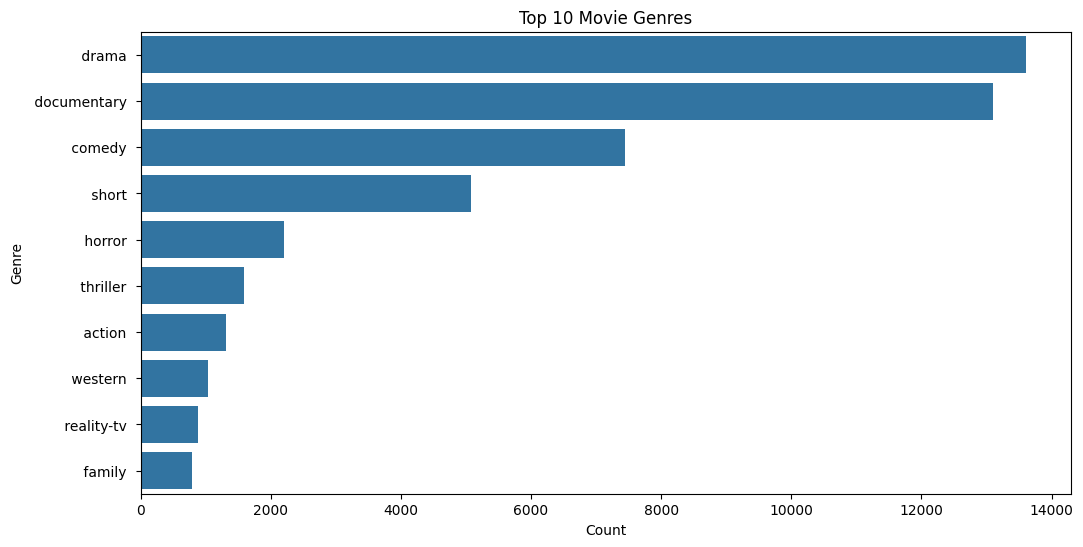

In [16]:
# ==========================================
# VISUALIZE TOP MOVIE GENRES
# ==========================================

plt.figure(figsize=(12, 6))

sns.countplot(
    y='GENRE',
    data=df,
    order=df['GENRE'].value_counts().index[:10]
)

plt.title("Top 10 Movie Genres")

plt.xlabel("Count")

plt.ylabel("Genre")

plt.show()

In [18]:
# ==========================================
# DEFINE FEATURES AND TARGET
# ==========================================

X = df['DESCRIPTION']

y = df['GENRE']

In [21]:
# ==========================================
# SPLIT DATASET
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
# ==========================================
# TF-IDF VECTORIZATION
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)


X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

In [23]:
# ==========================================
# IMPORT NAIVE BAYES CLASSIFIER
# ==========================================

from sklearn.naive_bayes import MultinomialNB

In [24]:
# ==========================================
# CREATE NAIVE BAYES MODEL
# ==========================================

naive_bayes_model = MultinomialNB()

In [26]:
# ==========================================
# TRAIN THE MODEL
# ==========================================

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

nb_predictions = naive_bayes_model.predict(
    X_test_tfidf
)

In [28]:
# ==========================================
# CALCULATE ACCURACY
# ==========================================

from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:")

print(round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy:
52.32 %


In [29]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    nb_predictions
))

               precision    recall  f1-score   support

      action        0.58      0.08      0.14       263
       adult        0.88      0.06      0.12       112
   adventure        0.29      0.03      0.05       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.44      0.47      1443
       crime        0.00      0.00      0.00       107
 documentary        0.58      0.88      0.70      2659
       drama        0.46      0.83      0.59      2697
      family        1.00      0.01      0.01       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.15      0.26        40
     history        0.00      0.00      0.00        45
      horror        0.73      0.36      0.48       431
       music        0.77      0.12      0.20       144
     musical        0.00      0.00      0.00        50
     mystery        0.00      0.00      0.00        56
        n

c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [30]:
# ==========================================
# IMPORT LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

In [31]:
# ==========================================
# CREATE LOGISTIC REGRESSION MODEL
# ==========================================

logistic_model = LogisticRegression(
    max_iter=1000
)

In [32]:
# ==========================================
# TRAIN MODEL
# ==========================================

logistic_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

lr_predictions = logistic_model.predict(
    X_test_tfidf
)


In [34]:
# ==========================================
# CALCULATE ACCURACY
# ==========================================

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:")

print(round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy:
57.93 %


In [35]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print(classification_report(
    y_test,
    lr_predictions
))

               precision    recall  f1-score   support

      action        0.53      0.27      0.35       263
       adult        0.71      0.21      0.33       112
   adventure        0.42      0.14      0.21       139
   animation        0.61      0.11      0.18       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.58      0.55      1443
       crime        0.43      0.03      0.05       107
 documentary        0.66      0.85      0.74      2659
       drama        0.54      0.78      0.64      2697
      family        0.41      0.07      0.12       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.94      0.42      0.59        40
     history        0.00      0.00      0.00        45
      horror        0.63      0.56      0.59       431
       music        0.62      0.47      0.54       144
     musical        1.00      0.02      0.04        50
     mystery        0.00      0.00      0.00        56
        n

c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [39]:
# ==========================================
# IMPORT SUPPORT VECTOR MACHINE
# ==========================================

from sklearn.svm import LinearSVC

In [40]:
# ==========================================
# CREATE SVM MODEL
# ==========================================

svm_model = LinearSVC()

In [41]:
# ==========================================
# TRAIN THE MODEL
# ==========================================

svm_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [42]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

svm_predictions = svm_model.predict(
    X_test_tfidf
)

In [43]:
# ==========================================
# CALCULATE ACCURACY
# ==========================================

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print("Support Vector Machine Accuracy:")

print(round(svm_accuracy * 100, 2), "%")

Support Vector Machine Accuracy:
57.04 %


In [44]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print(classification_report(
    y_test,
    svm_predictions
))

               precision    recall  f1-score   support

      action        0.43      0.32      0.37       263
       adult        0.59      0.41      0.48       112
   adventure        0.31      0.22      0.25       139
   animation        0.35      0.18      0.24       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.56      0.54      1443
       crime        0.21      0.07      0.10       107
 documentary        0.69      0.81      0.74      2659
       drama        0.56      0.71      0.63      2697
      family        0.26      0.13      0.17       150
     fantasy        0.08      0.01      0.02        74
   game-show        0.79      0.68      0.73        40
     history        0.00      0.00      0.00        45
      horror        0.60      0.63      0.62       431
       music        0.56      0.54      0.55       144
     musical        0.00      0.00      0.00        50
     mystery        0.14      0.04      0.06        56
        n

In [45]:
# ==========================================
# MODEL ACCURACY COMPARISON
# ==========================================

print("Naive Bayes Accuracy :",
      round(nb_accuracy * 100, 2), "%")

print("Logistic Regression Accuracy :",
      round(lr_accuracy * 100, 2), "%")

print("SVM Accuracy :",
      round(svm_accuracy * 100, 2), "%")

Naive Bayes Accuracy : 52.32 %
Logistic Regression Accuracy : 57.93 %
SVM Accuracy : 57.04 %


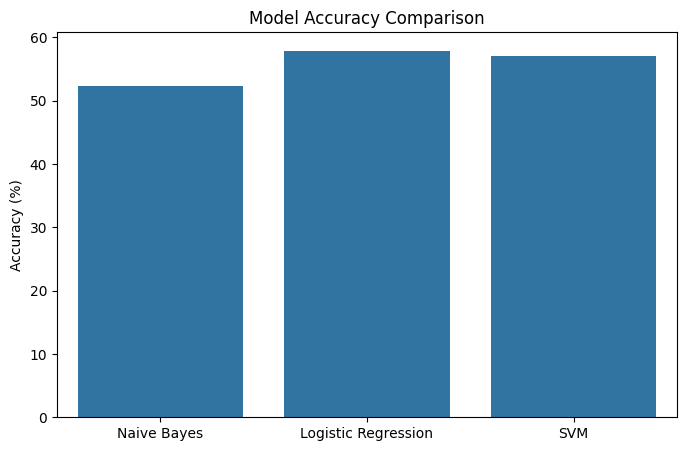

In [46]:
# ==========================================
# VISUALIZE MODEL ACCURACY
# ==========================================

models = [
    'Naive Bayes',
    'Logistic Regression',
    'SVM'
]

accuracies = [
    nb_accuracy * 100,
    lr_accuracy * 100,
    svm_accuracy * 100
]


plt.figure(figsize=(8, 5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy Comparison")

plt.show()

In [47]:
# ==========================================
# CUSTOM MOVIE GENRE PREDICTION
# ==========================================

sample_plot = """
A young wizard discovers magical powers
and fights dark forces to save the world.
"""


sample_vector = tfidf.transform(
    [sample_plot]
)


prediction = svm_model.predict(
    sample_vector
)

print("Predicted Genre:")

print(prediction[0])

Predicted Genre:
 fantasy 
